## Dataset

1. We use the Bank Marketing Dataset from the UCI Machine Learning Repository.
Source: https://archive.ics.uci.edu/ml/datasets/bank+marketing

2. The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. Originally designed for supervised learning, but we will ignore the label initially

Important Decision:

Even though the dataset contains subscribed (whether the client subscribed to a term deposit), we do not use it to train the clustering model.
We may, however, use it later for interpretation only.

    # bank client data:
    1 - age (numeric)
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    # related with the last contact of the current campaign:
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    # other attributes:
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    # social and economic context attributes
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 

df = bank_marketing.data.features 
print(bank_marketing.variables) 



           name     role         type      demographic  \
0           age  Feature      Integer              Age   
1           job  Feature  Categorical       Occupation   
2       marital  Feature  Categorical   Marital Status   
3     education  Feature  Categorical  Education Level   
4       default  Feature       Binary             None   
5       balance  Feature      Integer             None   
6       housing  Feature       Binary             None   
7          loan  Feature       Binary             None   
8       contact  Feature  Categorical             None   
9   day_of_week  Feature         Date             None   
10        month  Feature         Date             None   
11     duration  Feature      Integer             None   
12     campaign  Feature      Integer             None   
13        pdays  Feature      Integer             None   
14     previous  Feature      Integer             None   
15     poutcome  Feature  Categorical             None   
16            

## task 1

### Requirements

The goal of this lab is to **explore the bank dataset, prepare it for clustering, and apply K-Means**.  
Follow these steps carefully and write down your observations.  

### **Exploratory Data Analysis (EDA)** (understanding the dataset and its characteristics)

For each feature, you should:

- Identify **numeric vs categorical features**  
- Check **distributions** of numeric features (min, max, mean, std, skewness)  
- Check **counts of categories** for categorical features  
- Identify **missing or unknown values** and decide how to handle them  
- Look for **correlations** between numeric features  
- Identify **outliers** that may affect clustering  

In [2]:
###Identify numeric vs categorical features###

import pandas as pd

# Numeric features
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical features
categorical_features = df.select_dtypes(include=['object']).columns

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numeric Features:
Index(['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous'],
      dtype='object')

Categorical Features:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')


               count         mean          std     min    25%    50%     75%  \
age          45211.0    40.936210    10.618762    18.0   33.0   39.0    48.0   
balance      45211.0  1362.272058  3044.765829 -8019.0   72.0  448.0  1428.0   
day_of_week  45211.0    15.806419     8.322476     1.0    8.0   16.0    21.0   
duration     45211.0   258.163080   257.527812     0.0  103.0  180.0   319.0   
campaign     45211.0     2.763841     3.098021     1.0    1.0    2.0     3.0   
pdays        45211.0    40.197828   100.128746    -1.0   -1.0   -1.0    -1.0   
previous     45211.0     0.580323     2.303441     0.0    0.0    0.0     0.0   

                  max   skewness  
age              95.0   0.684818  
balance      102127.0   8.360308  
day_of_week      31.0   0.093079  
duration       4918.0   3.144318  
campaign         63.0   4.898650  
pdays           871.0   2.615715  
previous        275.0  41.846454  


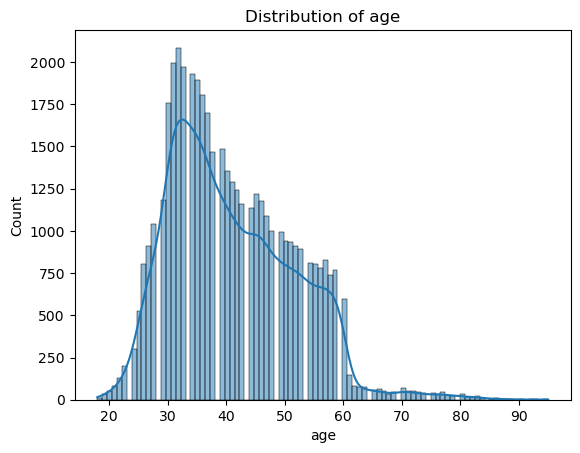

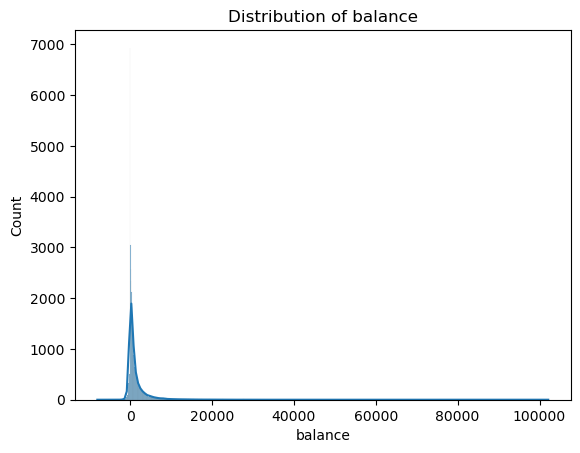

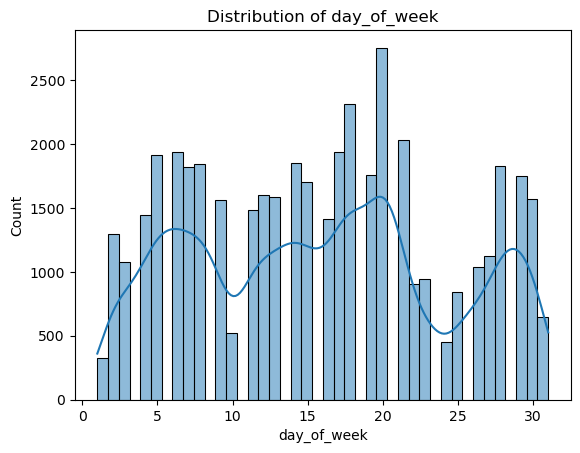

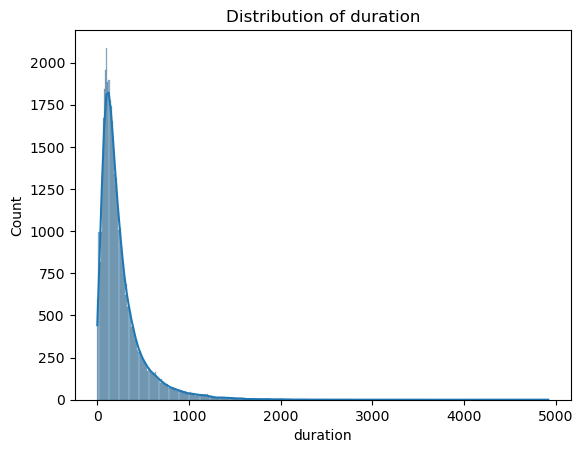

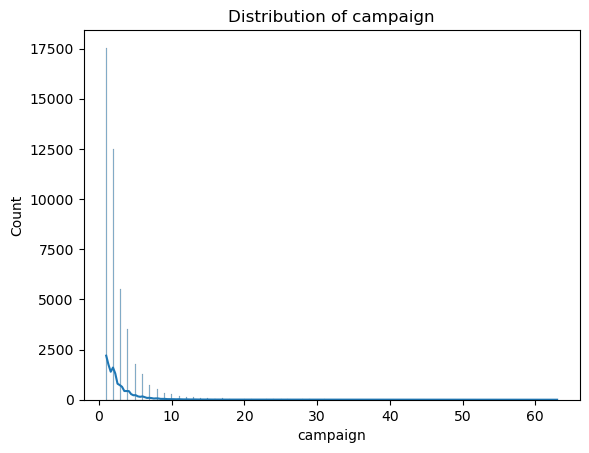

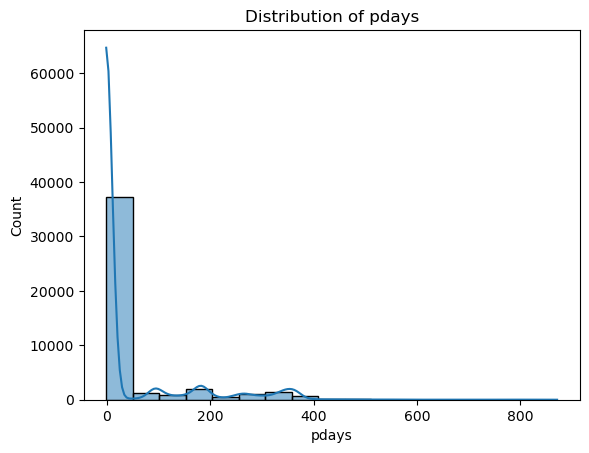

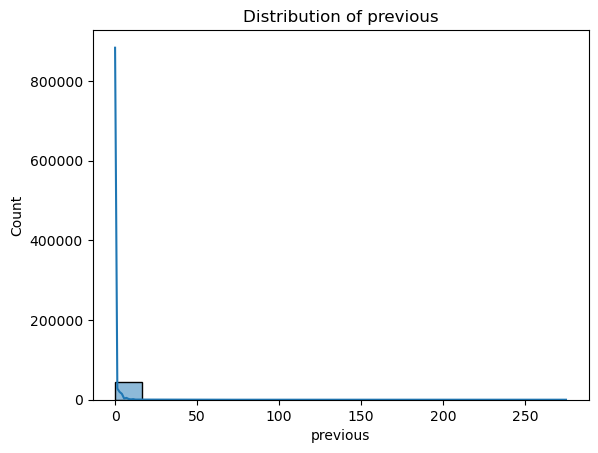

In [3]:
###Check distributions of numeric features (min, max, mean, std, skewness)###

import seaborn as sns
import matplotlib.pyplot as plt


df[numeric_features].describe()
stats = df[numeric_features].describe().T
stats['skewness'] = df[numeric_features].skew()

print(stats)


for col in numeric_features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


Feature: job
               Count  Percentage (%)
blue-collar     9732           21.66
management      9458           21.05
technician      7597           16.91
admin.          5171           11.51
services        4154            9.25
retired         2264            5.04
self-employed   1579            3.51
entrepreneur    1487            3.31
unemployed      1303            2.90
housemaid       1240            2.76
student          938            2.09

Feature: marital
          Count  Percentage (%)
married   27214           60.19
single    12790           28.29
divorced   5207           11.52

Feature: education
           Count  Percentage (%)
secondary  23202           53.52
tertiary   13301           30.68
primary     6851           15.80

Feature: default
     Count  Percentage (%)
no   44396            98.2
yes    815             1.8

Feature: housing
     Count  Percentage (%)
yes  25130           55.58
no   20081           44.42

Feature: loan
     Count  Percentage (%)
no  

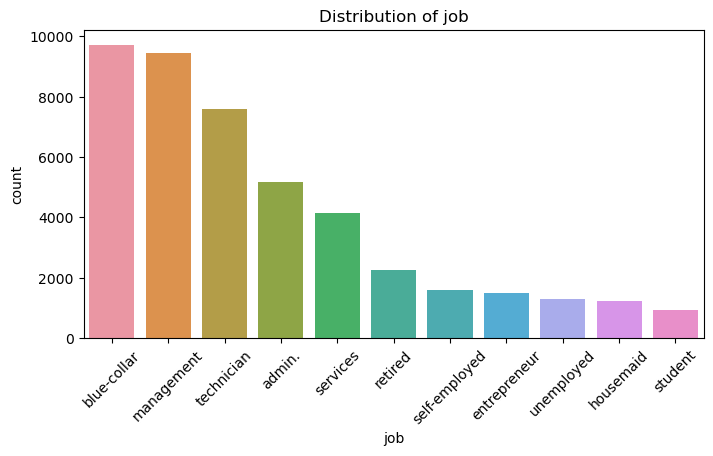

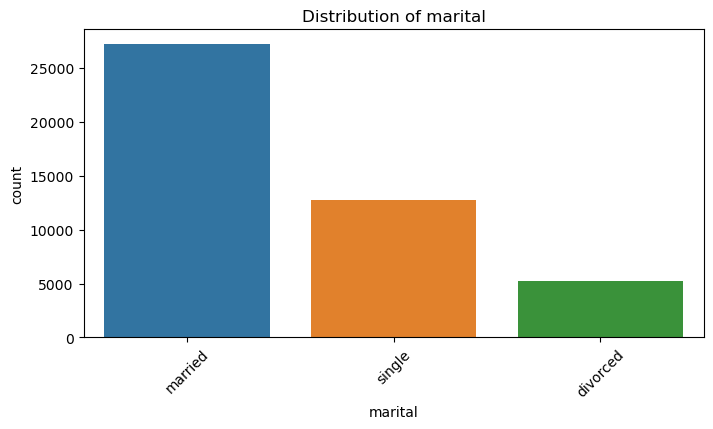

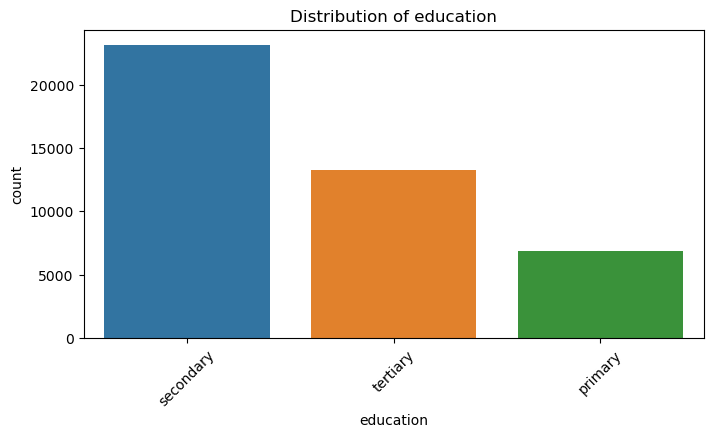

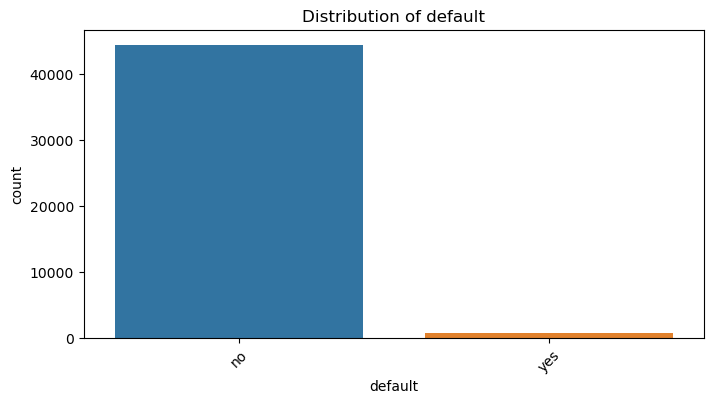

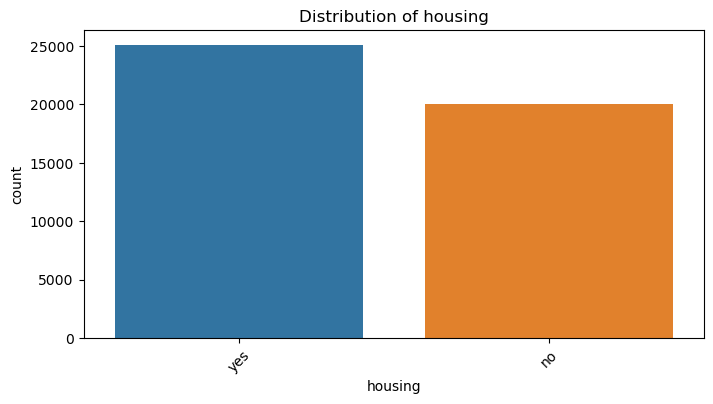

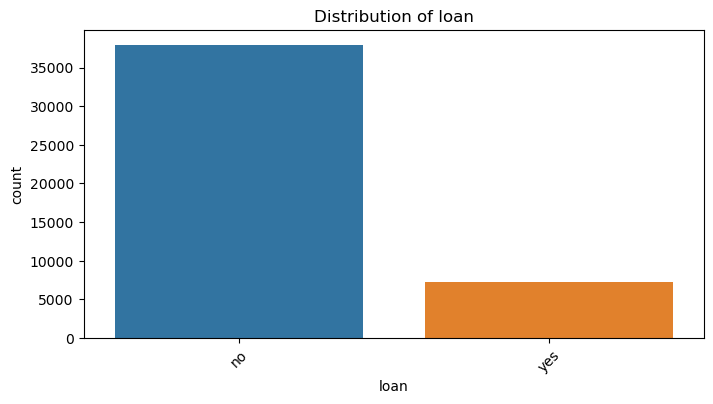

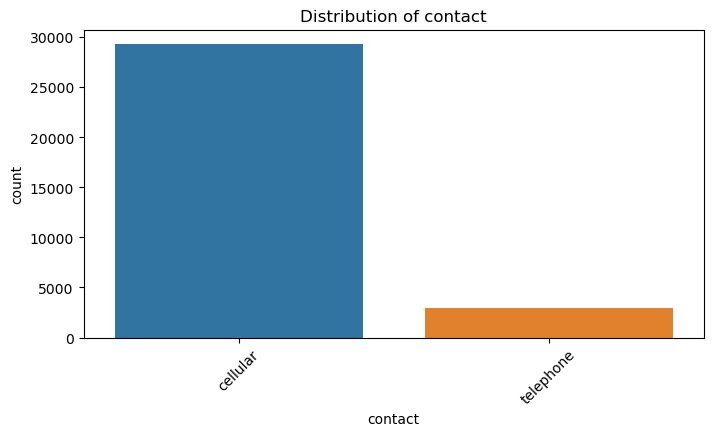

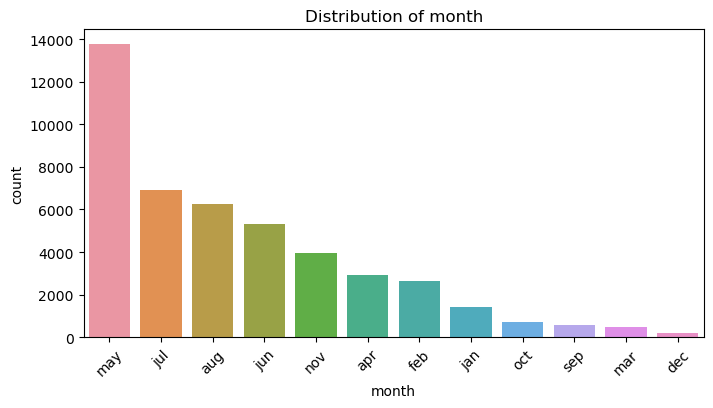

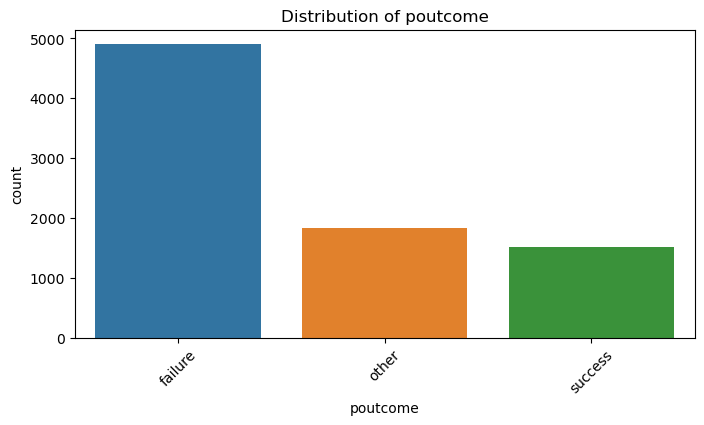

In [4]:
###Check counts of categories for categorical features###
import seaborn as sns
import matplotlib.pyplot as plt

for col in categorical_features:
    print(f"\nFeature: {col}")
    
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    
    summary = pd.DataFrame({
        'Count': counts,
        'Percentage (%)': percentages.round(2)
    })
    
    print(summary)
    

for col in categorical_features:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {col}')
    plt.show()

In [5]:
###Identify missing or unknown values and decide how to handle them##
df.isnull().sum()


for col in categorical_features:
    df[col] = df[col].fillna('Missing')
df['previous_contacted'] = (df['pdays'] != -1).astype(int)



C:\Users\Zeyad\AppData\Local\Temp\ipykernel_28152\2274763021.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna('Missing')


For categorical features, missing values are replaced with the category "Missing".
This approach preserves the information that data was unavailable, instead of dropping observations or arbitrarily imputing values.
In clustering, retaining such information may help identify patterns related to incomplete customer records.

The variable pdays indicates the number of days since the client was last contacted.
A value of -1 represents that the client was never contacted before.
Instead of treating -1 as a numeric value, we transform this information into a binary feature

In [6]:
df.isnull().sum()


age                   0
job                   0
marital               0
education             0
default               0
balance               0
housing               0
loan                  0
contact               0
day_of_week           0
month                 0
duration              0
campaign              0
pdays                 0
previous              0
poutcome              0
previous_contacted    0
dtype: int64

This shows that all the missing values have been mitigated

                  age   balance  day_of_week  duration  campaign     pdays  \
age          1.000000  0.097783    -0.009120 -0.004648  0.004760 -0.023758   
balance      0.097783  1.000000     0.004503  0.021560 -0.014578  0.003435   
day_of_week -0.009120  0.004503     1.000000 -0.030206  0.162490 -0.093044   
duration    -0.004648  0.021560    -0.030206  1.000000 -0.084570 -0.001565   
campaign     0.004760 -0.014578     0.162490 -0.084570  1.000000 -0.088628   
pdays       -0.023758  0.003435    -0.093044 -0.001565 -0.088628  1.000000   
previous     0.001288  0.016674    -0.051710  0.001203 -0.032855  0.454820   

             previous  
age          0.001288  
balance      0.016674  
day_of_week -0.051710  
duration     0.001203  
campaign    -0.032855  
pdays        0.454820  
previous     1.000000  


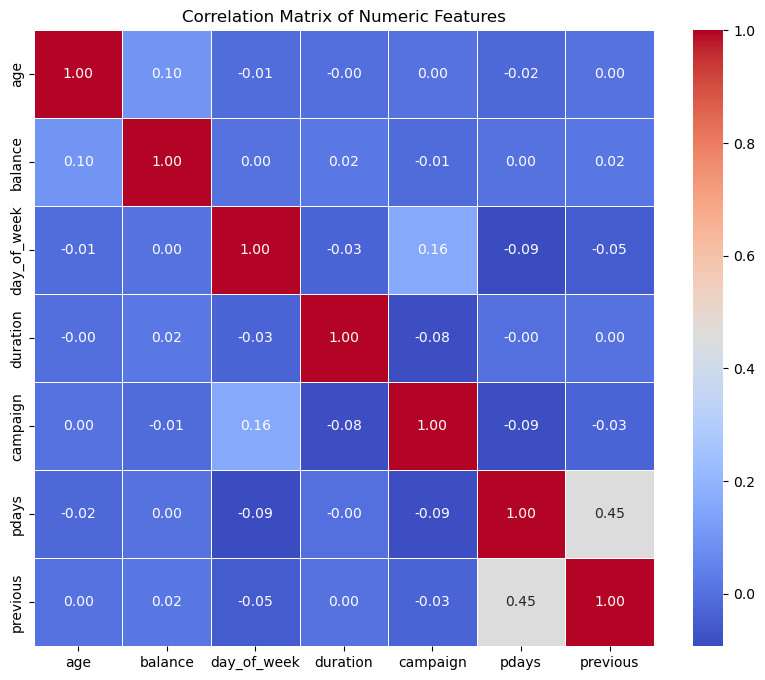

In [7]:
###Look for correlations between numeric features##
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df[numeric_features].corr()

print(corr_matrix)



plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Matrix of Numeric Features")
plt.show()

Not much correlation, which wont help me in determining wich features to drop :(

{'age': 487, 'balance': 4729, 'day_of_week': 0, 'duration': 3235, 'campaign': 3064, 'pdays': 8257, 'previous': 8257}


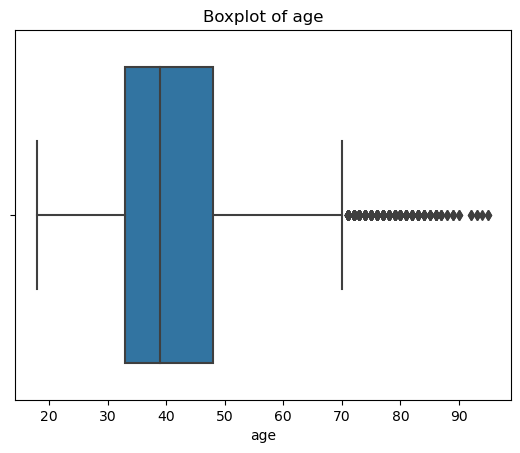

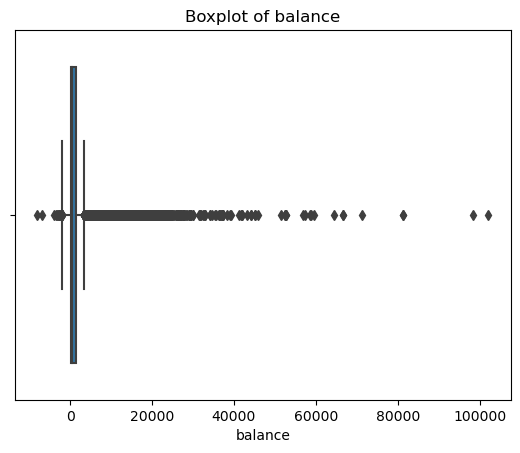

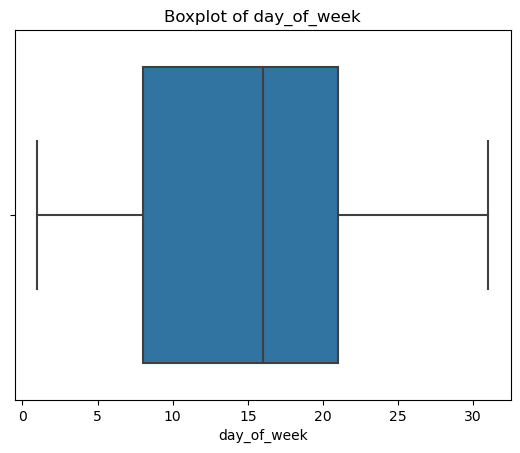

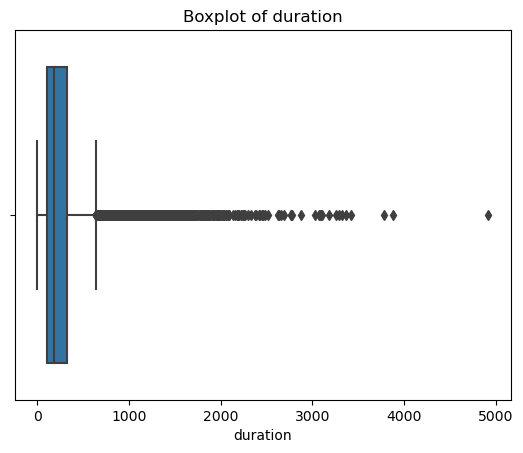

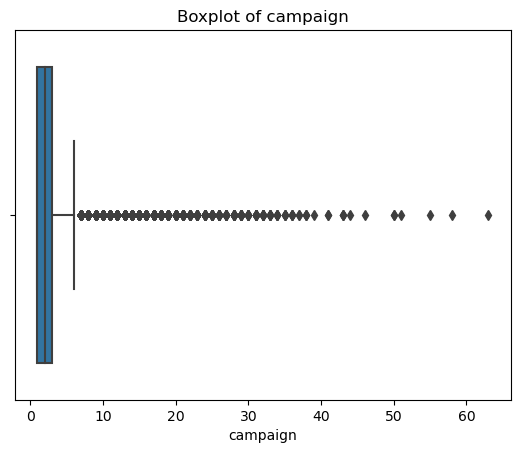

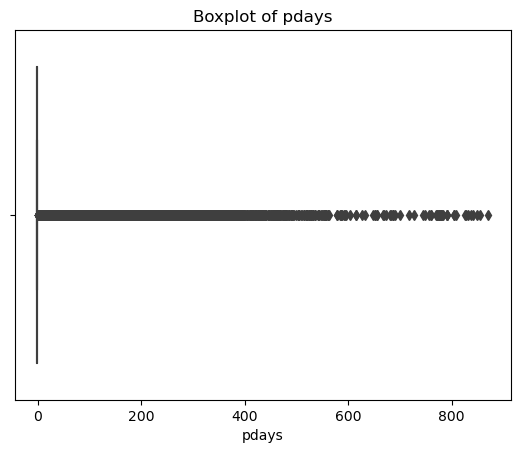

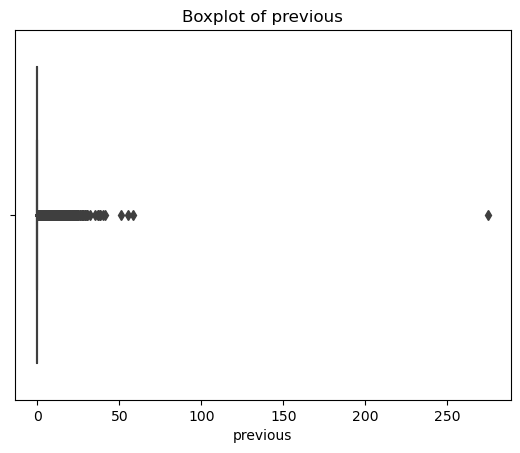

In [8]:
###Identify outliers that may affect clustering###

numeric_features = numeric_features.drop('y_num', errors='ignore')

import numpy as np

outlier_summary = {}

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary[col] = len(outliers)

print(outlier_summary)

import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric_features:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Some of the feature like 'balance' and 'duration' show high values of skew or outlierness, which may help in  dtermining which features to drop 

In [9]:
df.head(20)

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,previous_contacted
0,58,management,married,tertiary,no,2143,yes,no,Missing,5,may,261,1,-1,0,Missing,0
1,44,technician,single,secondary,no,29,yes,no,Missing,5,may,151,1,-1,0,Missing,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,Missing,5,may,76,1,-1,0,Missing,0
3,47,blue-collar,married,Missing,no,1506,yes,no,Missing,5,may,92,1,-1,0,Missing,0
4,33,Missing,single,Missing,no,1,no,no,Missing,5,may,198,1,-1,0,Missing,0
5,35,management,married,tertiary,no,231,yes,no,Missing,5,may,139,1,-1,0,Missing,0
6,28,management,single,tertiary,no,447,yes,yes,Missing,5,may,217,1,-1,0,Missing,0
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,Missing,5,may,380,1,-1,0,Missing,0
8,58,retired,married,primary,no,121,yes,no,Missing,5,may,50,1,-1,0,Missing,0
9,43,technician,single,secondary,no,593,yes,no,Missing,5,may,55,1,-1,0,Missing,0


### **Data Preparation**

Before applying K-Means:

- Drop irrelevant or target columns
- Encode categorical features into numeric format
- Scale numeric features so all are comparable for distance calculations  
- Check that the final dataset has **no missing values** and **all features are numeric**  

In [10]:
if 'duration' in df.columns:
    df = df.drop(columns=['duration'])

if 'pdays' in df.columns:
    df = df.drop(columns=['pdays'])
    
df.tail(5)

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,campaign,previous,poutcome,previous_contacted
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,3,0,Missing,0
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,2,0,Missing,0
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,5,3,success,1
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,4,0,Missing,0
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,2,11,other,1


The feature duration (call duration) is removed prior to clustering.
This variable represents the length of the marketing call and is only known after the interaction has occurred.
Including it would introduce information leakage and bias clustering toward campaign outcomes rather than intrinsic customer characteristics.
Therefore, it is excluded to ensure fair and meaningful segmentation.

The feature pdays indicates the number of days since the client was last contacted.
Since we previously transformed this information into a binary feature (previous_contacted), retaining pdays would introduce redundancy and potential distortion due to its special value (-1).
Therefore, it is removed to avoid misleading numerical interpretations and multicollinearity.

In [11]:

df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=False)
df_encoded.head(5)

,age,balance,day_of_week,campaign,previous,previous_contacted,job_Missing,job_admin.,job_blue-collar,job_entrepreneur,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_Missing,poutcome_failure,poutcome_other,poutcome_success
0,58,2143,5,1,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
1,44,29,5,1,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
2,33,2,5,1,0,0,0,0,0,1,...,0,0,1,0,0,0,1,0,0,0
3,47,1506,5,1,0,0,0,0,1,0,...,0,0,1,0,0,0,1,0,0,0
4,33,1,5,1,0,0,1,0,0,0,...,0,0,1,0,0,0,1,0,0,0


In [12]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age', 'balance', 'day_of_week']

scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])
df_encoded.head(5)

,age,balance,day_of_week,campaign,previous,previous_contacted,job_Missing,job_admin.,job_blue-collar,job_entrepreneur,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_Missing,poutcome_failure,poutcome_other,poutcome_success
0,1.606965,0.256419,-1.298476,1,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
1,0.288529,-0.437895,-1.298476,1,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
2,-0.747384,-0.446762,-1.298476,1,0,0,0,0,0,1,...,0,0,1,0,0,0,1,0,0,0
3,0.571051,0.047205,-1.298476,1,0,0,0,0,1,0,...,0,0,1,0,0,0,1,0,0,0
4,-0.747384,-0.447091,-1.298476,1,0,0,1,0,0,0,...,0,0,1,0,0,0,1,0,0,0


In [13]:
non_numeric_cols = df_encoded.select_dtypes(exclude='number').columns
print(non_numeric_cols)

Index([], dtype='object')


### **Apply K-Means Clustering**

- Decide an initial number of clusters (K)  
- Fit the K-Means model to your prepared dataset  
- Assign each data point to a cluster

In [14]:
from sklearn.cluster import KMeans
k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10   # stability
)

In [15]:
kmeans.fit(df_encoded)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [16]:
labels = kmeans.fit_predict(df_encoded)
df_encoded['cluster'] = labels
df_encoded.head()

,age,balance,day_of_week,campaign,previous,previous_contacted,job_Missing,job_admin.,job_blue-collar,job_entrepreneur,...,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_Missing,poutcome_failure,poutcome_other,poutcome_success,cluster
0,1.606965,0.256419,-1.298476,1,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,3
1,0.288529,-0.437895,-1.298476,1,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,3
2,-0.747384,-0.446762,-1.298476,1,0,0,0,0,0,1,...,0,1,0,0,0,1,0,0,0,3
3,0.571051,0.047205,-1.298476,1,0,0,0,0,1,0,...,0,1,0,0,0,1,0,0,0,3
4,-0.747384,-0.447091,-1.298476,1,0,0,1,0,0,0,...,0,1,0,0,0,1,0,0,0,3


### **Choosing the Convenient K**

- Use **Elbow Method**: plot Sum of Squared Distances (SSD) vs K  
- Identify the **elbow point** where SSD reduction slows  
- Calculate **Silhouette scores** to validate K  

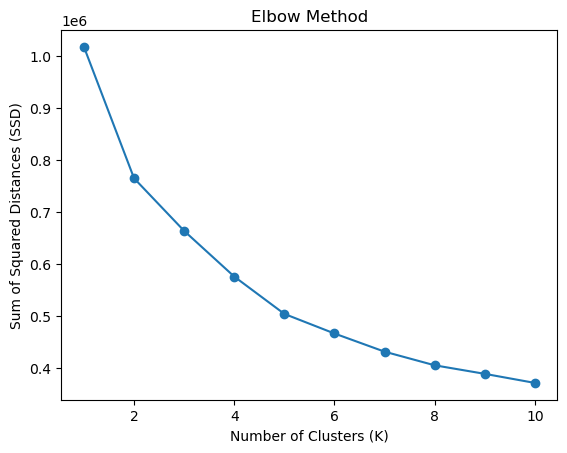

In [17]:
import numpy as np

X = df_encoded.drop(columns=['cluster'], errors='ignore').to_numpy(dtype=np.float64)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ssd = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    ssd.append(kmeans.inertia_)
    
plt.figure()
plt.plot(K_range, ssd, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Sum of Squared Distances (SSD)")
plt.title("Elbow Method")
plt.show()

In [18]:
!pip install kneed
from kneed import KneeLocator

kneedle = KneeLocator(K_range, ssd, curve='convex', direction='decreasing')
print("Elbow at K =", kneedle.elbow)

Elbow at K = 5


The elbow is at K=5 but i should still do a Silhouette score test since this value may not be suitable for this dataset

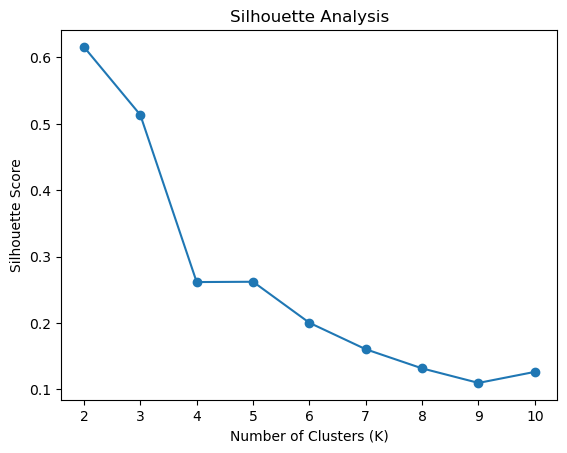

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

X = df_encoded.drop(columns=['cluster'], errors='ignore').to_numpy(dtype=np.float64)
scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    
plt.figure()
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

The Elbow Method suggests an optimal value of K = 5, indicating diminishing returns in within-cluster variance beyond this point.
However, Silhouette analysis shows the highest separation at K = 2, suggesting that the dataset naturally forms two strongly separated groups. This may be an idication that the elbow method is not suitable for finding the K for this dataset.